Getting VizDoom up and running


In [1]:
%pip install vizdoom


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
%cd github & git clone https://github.com/mwydmuch/ViZDoom

[WinError 123] The filename, directory name, or volume label syntax is incorrect: 'github & git clone https://github.com/mwydmuch/ViZDoom'
c:\Users\navee\OneDrive\Documents\SEM-6\reinforcement_learning\Project\VizDoom\VizDoom


c:\Users\navee\Envs\RL_ENV\lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [3]:
#import vizdoom for the env
from vizdoom import *
#import random for the action sampling
import random
#import time for sleeping 
import time
#import numpy for identity matrix
import numpy as np

In [4]:
#Game setup
game = DoomGame()
game.load_config('github/VizDoom/scenarios/basic.cfg')  #to load the specific configuratons
game.init()

In [5]:
#this is set the actions we can take in the environment
actions = np.identity(3,dtype=np.uint8) #create's a 3*3 identity matrix

In [6]:

print("left move:",actions[0])

print("right move:",actions[1])
print("attack:",actions[2])


left move: [1 0 0]
right move: [0 1 0]
attack: [0 0 1]


In [7]:
random.choice(actions)

array([0, 1, 0], dtype=uint8)

In [8]:
# game.new_episode()
# game.is_episode_finished()
#game.make_action(random.choice(actions))

In [9]:
# state = game.get_state()
# state.screen_buffer  # cotains an numpy array of img 
# info = state.game_variables   #game variable asuch as ammo
# info

In [10]:
#loop through episodes
episodes=10
for episode in range(episodes):
    #create a new episode or game 
    game.new_episode()
    #check the game isn't done
    while not game.is_episode_finished():
        #get the game state
        state = game.get_state()
        #get the game image
        img = state.screen_buffer
        #get the game variable- Ammo
        info = state.game_variables
        #take an action
        reward = game.make_action(random.choice(actions) ,4 ) #helps to skip the frames while visualizing.
        #print reward
        print('reward :',reward)
        time.sleep(0.02) #time for the break in millli seconds
    print('Result:',game.get_total_reward())
    time.sleep(2)



reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : 97.0
reward : -1.0
Result: -211.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -4.0
reward : -9.0
rewar

In [11]:
game.close()

2.Converting it to the Open Ai Gym wnvironment

In [12]:
%pip install gym
%pip install opencv-python



Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [13]:
import gymnasium as gym
#import environment base class from the OpenAI gym
from gym import Env
#import gym spaces
from gym.spaces import Discrete,Box
#import opencv
import cv2

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [14]:
Discrete(3).sample() #random choice selection
actions[Discrete(3).sample()]

array([0, 0, 1], dtype=uint8)

In [15]:
Box(low = 0,high=255,shape=(224,224),dtype=np.uint8).sample()

array([[105, 203, 167, ..., 209, 105,  44],
       [ 98, 186,  81, ..., 244, 237, 178],
       [ 12, 120,  58, ...,  84, 120, 194],
       ...,
       [104,   3, 254, ..., 178, 156, 113],
       [192, 122,  75, ..., 121, 215,  74],
       [ 24, 232,  45, ..., 174,  91, 159]], dtype=uint8)

In [38]:
#create a base class VizDoom Environment
class VizDoomGym(Env):
    #Funtion that is called when we call the env
    def __init__(self, render=False):
        #inherit form Env
        super().__init__()
        
        #Game setup
        self.game = DoomGame()
        self.game.load_config('github/VizDoom/scenarios/basic.cfg')  #to load the specific configuratons
        
        
        #Render frame logic
        if render==False:
            self.game.set_window_visible(False)
        else:
            self.game.set_window_visible(True)
            
        self.game.init()
        
        #create an action and observation space
        self.observation_space= Box(low=0,high=255,shape=(100,160,1),dtype=np.uint8)
        self.action_space = Discrete(3)
        
        pass
    
    #this is how we take a step in the environment 
    def step(self,action):
        #Specify action and take step
        actions = np.identity(3,dtype=np.uint8) #create's a 3*3 identity matrix
        reward = self.game.make_action(actions[action],4)
        
        if self.game.get_state():
            state=self.game.get_state().screen_buffer
            state = self.grayscale(state)
            ammo = self.game.get_state().game_variables[0]
            info=ammo
        else:
            state = np.zeros(self.observation_space.shape)
            info =0 
        info={"info":info}
        done = self.game.is_episode_finished()
        
        return state,reward,done,info
    
    #Define how to render the game or environment
    def render(self):
        pass
    
    #What happens when we start a new game
    def reset(self):
        self.game.new_episode()
        state =  self.game.get_state().screen_buffer
        return self.grayscale(state)
        
    
    #Grayscale the game frame and resize it
    def grayscale(self, observation):
        gray = cv2.cvtColor(np.moveaxis(observation,0,-1),cv2.COLOR_BGR2GRAY)
        resize = cv2.resize(gray,(160,100),interpolation=cv2.INTER_CUBIC)
        state = np.reshape(resize,(100,160,1))
        return state
    
    #Call to close down the game
    def close(self):
        self.game.close()
        pass

View game state


In [17]:
env =VizDoomGym(render=True)


In [18]:
state=env.reset()


In [19]:
env.step(2)

(array([[[55],
         [50],
         [59],
         ...,
         [57],
         [57],
         [66]],
 
        [[68],
         [65],
         [65],
         ...,
         [56],
         [67],
         [72]],
 
        [[49],
         [79],
         [66],
         ...,
         [79],
         [51],
         [29]],
 
        ...,
 
        [[75],
         [63],
         [62],
         ...,
         [44],
         [71],
         [60]],
 
        [[15],
         [48],
         [47],
         ...,
         [49],
         [69],
         [47]],
 
        [[22],
         [14],
         [26],
         ...,
         [57],
         [37],
         [39]]], dtype=uint8),
 -4.0,
 False,
 {'ammo': np.float64(50.0)})

In [20]:
env.reset()

array([[[55],
        [50],
        [59],
        ...,
        [57],
        [57],
        [66]],

       [[68],
        [65],
        [65],
        ...,
        [56],
        [67],
        [72]],

       [[49],
        [79],
        [66],
        ...,
        [79],
        [51],
        [29]],

       ...,

       [[75],
        [63],
        [62],
        ...,
        [44],
        [71],
        [60]],

       [[15],
        [48],
        [47],
        ...,
        [49],
        [69],
        [47]],

       [[22],
        [14],
        [26],
        ...,
        [57],
        [37],
        [39]]], dtype=uint8)

In [21]:
env.close()

In [22]:
# #import Env checker
# from stable_baselines3.common import env_checker
# env_checker.check_env(env, warn=True)

view state


In [23]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


3.Mark down


In [24]:
from matplotlib import pyplot as plt

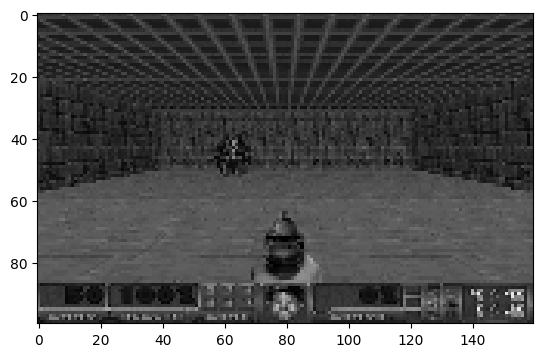

In [25]:
plt.imshow(cv2.cvtColor(state,cv2.COLOR_BGR2RGB))

Set Callback


In [26]:
%pip install torch torchvision torchaudio 


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [27]:
%pip install stable-baselines3

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [28]:
#Import os for file nav
import os
#import callback class form sb3
from stable_baselines3.common.callbacks import BaseCallback


In [29]:
class TrainAndLoggingCallback(BaseCallback):

    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(
                self.save_path,
                "best_model_{}".format(self.n_calls)
            )
            self.model.save(model_path)

        return True

In [30]:
CHECKPOINTS_DIR='./train/train_basic'
LOG_DIR='./logs/log_basic'


In [31]:
callback=TrainAndLoggingCallback(check_freq=10000,save_path=CHECKPOINTS_DIR)


Train Model


In [32]:
#IMPORT PPO FOR TRAININg
from stable_baselines3 import PPO

In [39]:
#non renter environmeant
env=VizDoomGym()

In [34]:
%pip install shimmy
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\navee\Envs\RL_ENV\Scripts\python.exe -m pip install --upgrade pip' command.


In [42]:
model=PPO('CnnPolicy',env,tensorboard_log=LOG_DIR,verbose=1,learning_rate=0.0001,n_steps=2048)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


In [43]:
model.learn(total_timesteps=10000,callback=callback)

Logging to ./logs/log_basic\PPO_4
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 27.3     |
|    ep_rew_mean     | -45.4    |
| time/              |          |
|    fps             | 14       |
|    iterations      | 1        |
|    time_elapsed    | 144      |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 27.2        |
|    ep_rew_mean          | -45.2       |
| time/                   |             |
|    fps                  | 16          |
|    iterations           | 2           |
|    time_elapsed         | 254         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009330994 |
|    clip_fraction        | 0.0705      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.000196 

In [ ]:
#activate the env in the command prompt 
#navigate to the ppo and run the command "tensorboard --logdir=." these shows the graph representation of all the selected log. 

Test The Model


In [51]:
#import evalution policy to test the model
from stable_baselines3.common.evaluation import evaluate_policy

In [ ]:
#reload model from the disc
model=PPO.load('./train/train_basic/best_model_10000')  ## load latest model everytime

In [53]:
#redered the environment
env=VizDoomGym(render=True)

In [54]:
mean_reward,_=evaluate_policy(model,env,n_eval_episodes=10)

In [55]:
mean_reward

np.float64(-300.0)

In [57]:
for episode in range(5):
    obs =env.reset()
    done= False
    total_reward=0
    while not done:
        action,_ =model.predict(obs)
        obs, reward, done, info =env.step(action)
        time.sleep(0.05)
        total_reward +=reward
    print('Total Reward for episode {} is {}'.format(total_reward, episode))
    time.sleep(2)

Total Reward for episode 91.0 is 0
Total Reward for episode 87.0 is 1
Total Reward for episode -268.0 is 2
Total Reward for episode -97.0 is 3
Total Reward for episode -375.0 is 4
